In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, QuantileTransformer,KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from collections import defaultdict
from tabulate import tabulate



RAW_DATA_PATH = "rocksdb_benchmark_results_sequential.csv"
PROCESSED_DATA_PATH = "rocksdb_benchmark_results_cleaned.csv"
ONE_HOT_ENCODING = 'one_hot'
DUMMY_ENCODING = 'dummy'
CATEGORICAL_VARIABLES = {'compaction_style', 'bloom_filter_policy', 'operation_type'}
MODEL_NAMES = {'mlp', 'xgb'}

class ModelConfig:
    def __init__(self, name: str, encoding_type: str, clean_data: bool):
        self.name = name
        self.encoding_type = encoding_type
        self.clean_data = clean_data

    def __hash__(self):
        return hash((self.name, self.encoding_type, self.clean_data))

    def __eq__(self, other):
        return (
            isinstance(other, ModelConfig)
            and self.name == other.name
            and self.encoding_type == other.encoding_type
            and self.clean_data == other.clean_data
        )

    def __repr__(self):
        return f"ModelConfig(name={self.name}, encoding_type={self.encoding_type}, clean_data={self.clean_data})"


class ModelResult:
    def __init__(self, model, mse, r2):
        self.model = model
        self.mse = mse
        self.r2 = r2

    def __repr__(self):
        return f"ModelResult(model={self.model}, mse={self.mse}, r2={self.r2})"


class ModelMap:
    def __init__(self):
        # Store results as: {op_type -> {model_name -> [(ModelConfig, ModelResult)]}}
        self.data = defaultdict(lambda: defaultdict(list))
        self.overall_results = defaultdict(list)  # Stores overall results per model_name

    def addIndivModelResult(self, op_type: str, model_config: ModelConfig, model_result: ModelResult):
        self.data[op_type][model_config.name].append((model_config, model_result))

    def addOverallModelResult(self, model_config: ModelConfig, model_result: ModelResult):
        self.overall_results[model_config.name].append((model_config, model_result))

    def __repr__(self):
        repr_str = "ModelMap:\n"
        for model_name in {name for op in self.data.values() for name in op} | set(self.overall_results):
            repr_str += f"\n=== Model: {model_name} ===\n"
            table_data = []
            
            # Add individual operation type results
            for op_type, models in self.data.items():
                if model_name in models:
                    for config, result in models[model_name]:
                        table_data.append([op_type, config.clean_data, config.encoding_type, result.mse, result.r2])

            # Add overall results
            for config, result in self.overall_results.get(model_name, []):
                table_data.append(["Overall", config.clean_data, config.encoding_type, result.mse, result.r2])

            repr_str += tabulate(table_data, headers=["Op Type", "Clean Data", "Encoding Type", "MSE", "R²"], tablefmt="grid")
            repr_str += "\n"

        return repr_str


def generate_configs(model_name: str):
    res = []
    for encoding_type in [ONE_HOT_ENCODING, DUMMY_ENCODING]:
        for i in range(2):
            res.append(ModelConfig(model_name, encoding_type=encoding_type, clean_data=bool(i)))
    return res

# MLP_CONFIG = ModelConfig(encoding_type=ONE_HOT_ENCODING, clean_data=True)
# XGB_CONFIG = ModelConfig(encoding_type=ONE_HOT_ENCODING, clean_data=True)


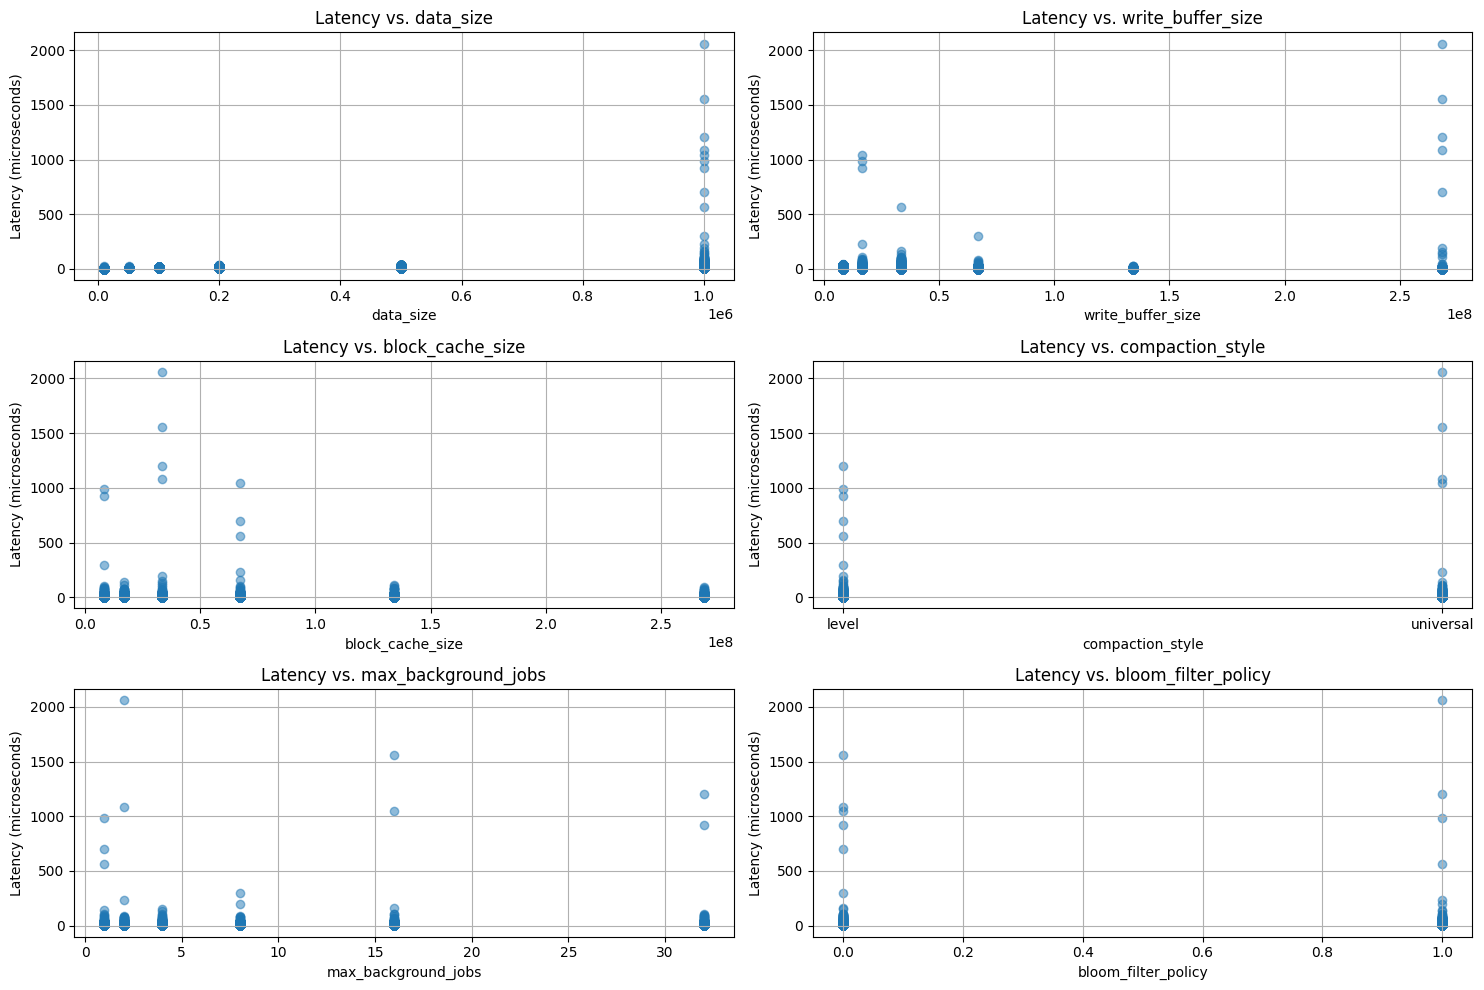

In [2]:

def parse_size_string(size_str):
    """
    Convert size strings like "64M" or "128M" to numeric values in bytes.
    """
    if isinstance(size_str, str):
        if size_str.endswith("K"):
            return int(size_str[:-1]) * 1024
        elif size_str.endswith("M"):
            return int(size_str[:-1]) * 1024 * 1024
        elif size_str.endswith("G"):
            
            return int(size_str[:-1]) * 1024 * 1024 * 1024
        else:
            return int(size_str)  # Assume bytes if no unit is specified
    return size_str  # Return as-is if already numeric


data = pd.read_csv(RAW_DATA_PATH)
data["write_buffer_size"] = data["write_buffer_size"].apply(parse_size_string)
data["block_cache_size"] = data["block_cache_size"].apply(parse_size_string)
data.to_csv(PROCESSED_DATA_PATH, index=False)

input_variables = ['data_size', 'write_buffer_size', 'block_cache_size', 
                   'compaction_style', 'max_background_jobs', 'bloom_filter_policy']


# Create scatter plots for each variable against latency
plt.figure(figsize=(15, 10))
for i, var in enumerate(input_variables, 1):
    plt.subplot(3, 2, i)  # Adjust grid size based on the number of variables
    plt.scatter(data[var], data['latency'], alpha=0.5)
    plt.xlabel(var)
    plt.ylabel("Latency (microseconds)")
    plt.title(f"Latency vs. {var}")
    plt.grid(True)

plt.tight_layout()
plt.show()

def get_dataframe(model_config: ModelConfig):
    data = pd.read_csv(PROCESSED_DATA_PATH, index_col=False)
    if model_config.clean_data:
        data["latency_zscore"] = (data["latency"] - data["latency"].mean()) / data["latency"].std()
        outliers = data[np.abs(data["latency_zscore"]) > 3]
        data = data[np.abs(data["latency_zscore"]) <= 3]
        del data["latency_zscore"]
    return data

In [3]:
# Define data-based constants
OPERATION_TYPES = pd.read_csv(PROCESSED_DATA_PATH)['operation_type'].unique()
model_map = ModelMap()

# MLP model

In [4]:
# --- Train and evaluate models for each operation type ---

def train_mlp_models(model_config: ModelConfig, model_map: ModelMap):
    print(f"#"*10, str(model_config), '#'*10)
    for op_type in OPERATION_TYPES:
        print(f"--- Training and evaluating for operation type: {op_type} ---")

        # Filter data for current operation type
        df_op = get_dataframe(model_config)
        df_op = df_op[df_op["operation_type"] == op_type]
        del df_op['operation_type']

        categorical_vars = CATEGORICAL_VARIABLES.copy()
        categorical_vars.remove('operation_type')
        categorical_vars = list(categorical_vars)
        # print(df_op.columns)

        if model_config.encoding_type == DUMMY_ENCODING:
            df_op = pd.get_dummies(df_op, columns=categorical_vars, drop_first=True)
            X_op = df_op.drop("latency", axis=1)
        elif model_config.encoding_type == ONE_HOT_ENCODING:
            ct = ColumnTransformer([('encoder', OneHotEncoder(drop='first'), categorical_vars)], remainder='passthrough')
            X_op = ct.fit_transform(df_op.drop("latency", axis=1))
        
        y_op = df_op["latency"]

        

        # Split data into training and testing sets (for current operation type)
        X_train_op, X_test_op, y_train_op, y_test_op = train_test_split(X_op, y_op, test_size=0.2, random_state=42)

        # Scale numerical features (fit and transform on training data for current operation type)
        scaler_op = StandardScaler()  # New scaler for each op type
        X_train_op_scaled = scaler_op.fit_transform(X_train_op)
        X_test_op_scaled = scaler_op.transform(X_test_op)

        # Train the model
        model_op = MLPRegressor(random_state=42, max_iter=10000)
        model_op.fit(X_train_op_scaled, y_train_op)

        # Make predictions
        y_pred_op = model_op.predict(X_test_op_scaled)

        # Evaluate the model
        mse_op = mean_squared_error(y_test_op, y_pred_op)
        r2_op = r2_score(y_test_op, y_pred_op)

        model_map.addIndivModelResult(op_type, model_config, ModelResult(model_op, mse_op, r2_op))

        print(f"Mean Squared Error ({op_type}): {mse_op}")
        print(f"R-squared ({op_type}): {r2_op}")
        print("-" * 50)


    # --- Overall model (trained on all data) ---
    print("\n--- Overall model (trained on all data) ---")

    df = get_dataframe(model_config)

    if model_config.encoding_type == DUMMY_ENCODING:
        df = pd.get_dummies(df, columns=list(CATEGORICAL_VARIABLES), drop_first=True)
        X = df.drop("latency", axis=1)
    elif model_config.encoding_type == ONE_HOT_ENCODING:
        ct = ColumnTransformer([('encoder', OneHotEncoder(drop='first'), list(CATEGORICAL_VARIABLES))], remainder='passthrough')
        X = ct.fit_transform(df.drop("latency", axis=1))
        

    y = df["latency"]

    X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_all_scaled = scaler.fit_transform(X_train_all)
    X_test_all_scaled = scaler.transform(X_test_all)

    model_all = MLPRegressor(random_state=42, max_iter=40000)
    model_all.fit(X_train_all_scaled, y_train_all)

    y_pred_all = model_all.predict(X_test_all_scaled)

    mse_all = mean_squared_error(y_test_all, y_pred_all)
    r2_all = r2_score(y_test_all, y_pred_all)

    model_map.addOverallModelResult(model_config, ModelResult(model_all, mse_all, r2_all))

    print(f"Mean Squared Error (Overall): {mse_all}")
    print(f"R-squared (Overall): {r2_all}")
    print("\n\n")

for model_config in generate_configs('mlp'):
    train_mlp_models(model_config, model_map)

########## ModelConfig(name=mlp, encoding_type=one_hot, clean_data=False) ##########
--- Training and evaluating for operation type: GET ---
Mean Squared Error (GET): 22.016354681239196
R-squared (GET): 0.8002650703701548
--------------------------------------------------
--- Training and evaluating for operation type: PUT ---
Mean Squared Error (PUT): 143.02114880656828
R-squared (PUT): -6.323157975753025
--------------------------------------------------
--- Training and evaluating for operation type: SEEK ---
Mean Squared Error (SEEK): 3.464576925903213
R-squared (SEEK): 0.9565290247743742
--------------------------------------------------

--- Overall model (trained on all data) ---
Mean Squared Error (Overall): 3278.116861689043
R-squared (Overall): 0.020603115685884466



########## ModelConfig(name=mlp, encoding_type=one_hot, clean_data=True) ##########
--- Training and evaluating for operation type: GET ---
Mean Squared Error (GET): 10.942961762994708
R-squared (GET): 0.8560361

In [5]:

def train_xgb_models(model_config: ModelConfig, model_map: ModelMap):
    print(f"#"*10, model_config, '#'*10)
    for op_type in OPERATION_TYPES:
        print(f"--- Training and evaluating for operation type: {op_type} ---")
        data = get_dataframe(model_config)
        data = data[data['operation_type'] == op_type]
        del data['operation_type']

        categorical_vars = CATEGORICAL_VARIABLES.copy()
        categorical_vars.remove('operation_type')
        categorical_vars = list(categorical_vars)

        if model_config.encoding_type == DUMMY_ENCODING:
            data = pd.get_dummies(data, columns=categorical_vars, drop_first=True)
            X = data.drop("latency", axis=1)
        elif model_config.encoding_type == ONE_HOT_ENCODING:
            ct = ColumnTransformer([('encoder', OneHotEncoder(drop='first'), categorical_vars)], remainder='passthrough')
            X = ct.fit_transform(data.drop("latency", axis=1))

        y = data["latency"]

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Define the model
        model = XGBRegressor(random_state=42)

        # Define hyperparameters to tune
        param_grid = {
            "n_estimators": [100, 200, 300],  # Number of boosting rounds
            "max_depth": [3, 5, 7],  # Maximum depth of a tree
            "learning_rate": [0.01, 0.1, 0.2],  # Learning rate
            "subsample": [0.8, 1.0],  # Fraction of samples used for training
            "colsample_bytree": [0.8, 1.0],  # Fraction of features used for training
        }

        # Perform grid search with cross-validation
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # Get the best model
        best_model = grid_search.best_estimator_

        # Evaluate the best model
        y_pred = best_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        model_map.addIndivModelResult(op_type, model_config, ModelResult(model, mse, r2))

        print(f"Best Hyperparameters: {grid_search.best_params_}")
        print(f"Mean Squared Error: {mse}")
        print(f"R-squared: {r2}")
        print("-" * 50)

    # --- Overall model (trained on all data) ---
    print("\n--- Overall model (trained on all data) ---")
    data = get_dataframe(model_config)
    if model_config.encoding_type == DUMMY_ENCODING:
        data = pd.get_dummies(data, columns=list(CATEGORICAL_VARIABLES), drop_first=True)
        X = data.drop("latency", axis=1)
    elif model_config.encoding_type == ONE_HOT_ENCODING:
        ct = ColumnTransformer([('encoder', OneHotEncoder(drop='first'), list(CATEGORICAL_VARIABLES))], remainder='passthrough')
        X = ct.fit_transform(data.drop("latency", axis=1))

    y = data["latency"]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define the model
    model = XGBRegressor(random_state=42)

    # Define hyperparameters to tune
    param_grid = {
        "n_estimators": [100, 200, 300],  # Number of boosting rounds
        "max_depth": [3, 5, 7],  # Maximum depth of a tree
        "learning_rate": [0.01, 0.1, 0.2],  # Learning rate
        "subsample": [0.8, 1.0],  # Fraction of samples used for training
        "colsample_bytree": [0.8, 1.0],  # Fraction of features used for training
    }

    # Perform grid search with cross-validation
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Evaluate the best model
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    model_map.addOverallModelResult(model_config, ModelResult(model, mse, r2))
    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {r2}")
    print("-" * 50)
    print("\n\n")

for model_config in generate_configs('xgb'):
    train_xgb_models(model_config, model_map)

########## ModelConfig(name=xgb, encoding_type=one_hot, clean_data=False) ##########
--- Training and evaluating for operation type: GET ---
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Mean Squared Error: 19.732297897338867
R-squared: 0.820986270904541
--------------------------------------------------
--- Training and evaluating for operation type: PUT ---
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Mean Squared Error: 297.8773498535156
R-squared: -14.252311706542969
--------------------------------------------------
--- Training and evaluating for operation type: SEEK ---
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Mean Squared Error: 2.646782875061035
R-squared: 0.9667900800704956
--------------------------------------------------

--- Overall

In [6]:
print(model_map)

ModelMap:

=== Model: xgb ===
+-----------+--------------+-----------------+-------------+-------------+
| Op Type   | Clean Data   | Encoding Type   |         MSE |          R² |
+===========+==============+=================+=============+=============+
| GET       | False        | one_hot         |   19.7323   |   0.820986  |
+-----------+--------------+-----------------+-------------+-------------+
| GET       | True         | one_hot         |   12.7073   |   0.832825  |
+-----------+--------------+-----------------+-------------+-------------+
| GET       | False        | dummy           |   19.7324   |   0.820986  |
+-----------+--------------+-----------------+-------------+-------------+
| GET       | True         | dummy           |   12.7073   |   0.832825  |
+-----------+--------------+-----------------+-------------+-------------+
| PUT       | False        | one_hot         |  297.877    | -14.2523    |
+-----------+--------------+-----------------+-------------+----------